# Adam, clipping, and learning-rate schedules

Runnable locally on CPU or on a Cloud TPU VM.

- Explain Adam’s moments, inspect clipping and schedule order, and compare optimizers with a controlled update budget.
- Calculate the first two Adam steps
- Clip a direction without rotating it
- Make the schedule clock explicit
- Compare decisions with evidence
- Bring the phase together in a training audit

An optimizer can lower the loss while hiding several choices: how it averages gradients, rescales coordinates, clips large values, and changes the step size. We will expose those choices one at a time before running a controlled comparison. The goal is to explain a training decision, not to crown a universal winner.

## The idea

Adam combines gradient history with coordinatewise scaling. Clipping limits a gradient or update according to a chosen rule, while a learning-rate schedule changes scale over training. These mechanisms interact, but we should inspect each separately before interpreting their combined loss curve.

## Clipping changes a vector; a schedule changes a clocked scale

Use the analytic gradient $g=(3,4)$, whose norm is $5$. Global-norm clipping at $2.5$ scales the entire vector to $(1.5,2)$, preserving its direction. Clipping each coordinate to the interval $[-2.5,2.5]$ instead produces $(2.5,2.5)$, whose direction and norm differ.

Now consider four microbatches accumulated into one optimizer update. A schedule indexed by optimizer updates should advance once for that group, not four times. The schedule's clock is part of the algorithm and should be restored with optimizer state.

The existing optimizer plot uses its labeled learning rates and shows nonmonotone trajectories, including rebounds. It compares that specific fixture; it does not demonstrate clipping or scheduling. Use the separate clipping diagram to understand the geometry, then test each mechanism with its own controlled change.

### A norm ball and a coordinate box

**Predict:** Does coordinate clipping at $2.5$ guarantee that the whole gradient norm is at most $2.5$?

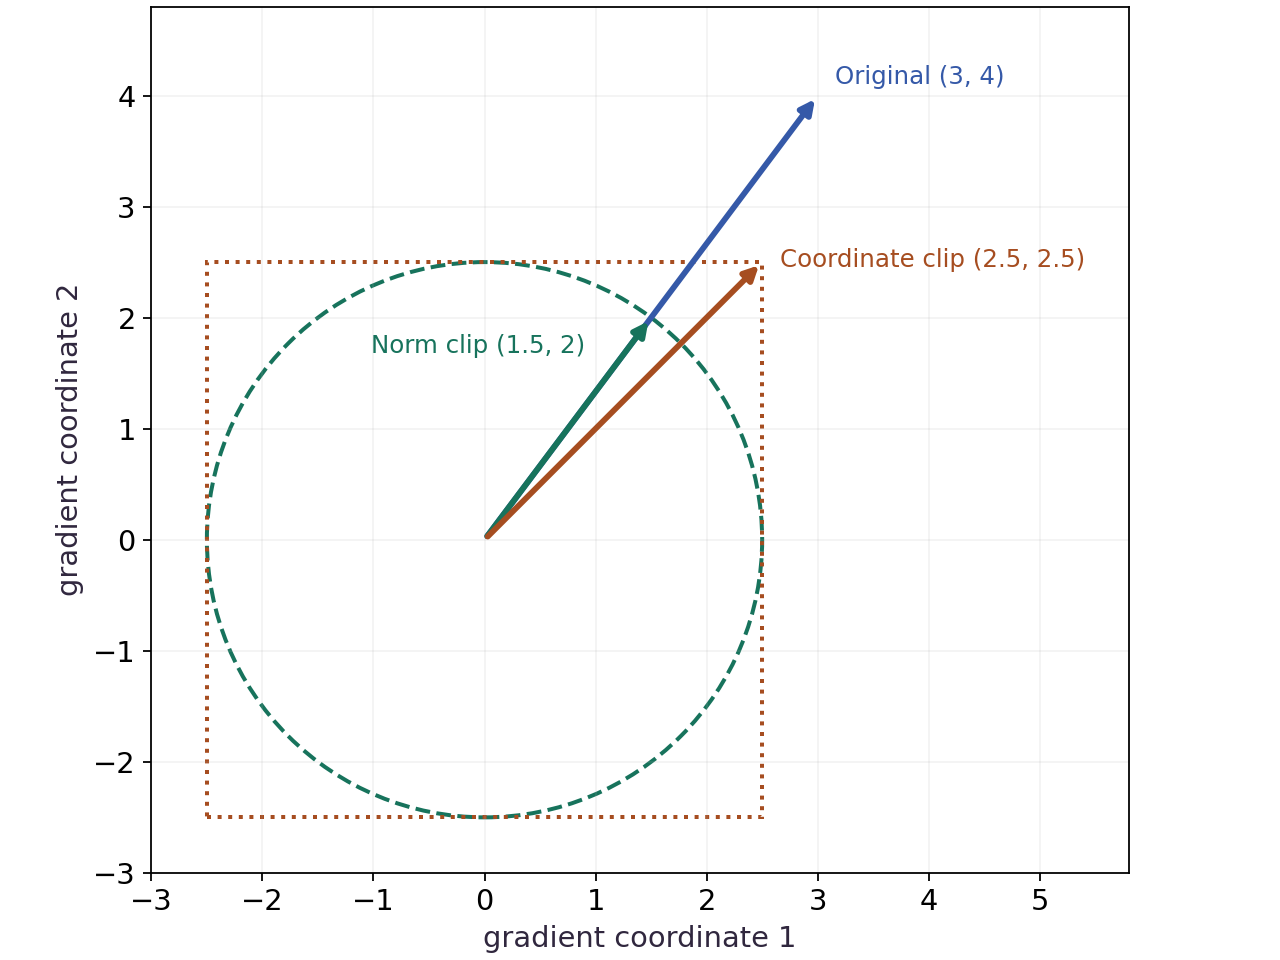

*Conceptual / analytic teaching diagram; not a recorded benchmark.*

The blue arrow is $(3,4)$. Green scales it to norm $2.5$ along the same ray. Orange clips each coordinate to $2.5$, landing at the box corner with norm $2.5\sqrt{2}$. The circle and box are analytic constraints, not training measurements.

### Pause and reason

Does coordinate clipping at $2.5$ guarantee that the whole gradient norm is at most $2.5$?

<details><summary>Compare your reasoning</summary>

No. For the clipped vector $(2.5,2.5)$, the norm is $2.5\sqrt{2}$. A coordinate bound describes a box; a global-norm bound describes a ball.

</details>

## Calculate the first two Adam steps

Let $g_t$ be the gradient at update $t$. Adam tracks a first moment $m_t$ and a second raw moment $v_t$, using decay rates $\beta_1$ and $\beta_2$. Starting at zero makes the early averages small; divide by $1-\beta_1^t$ and $1-\beta_2^t$ to correct that bias. At the first step, corrected moments are $g_1$ and $g_1^2$. With a small $\epsilon$, each nonzero coordinate initially moves close to the learning rate in the opposite sign direction. This does not mean later steps ignore magnitude.

$$
\begin{aligned}m_t&=\beta_1m_{t-1}+(1-\beta_1)g_t\\v_t&=\beta_2v_{t-1}+(1-\beta_2)g_t^2\\\hat m_t&=m_t/(1-\beta_1^t),\quad \hat v_t=v_t/(1-\beta_2^t)\\\Delta w_t&=-\eta_t\frac{\hat m_t}{\sqrt{\hat v_t}+\epsilon}\end{aligned}
$$

## Clip a direction without rotating it

Global norm clipping rescales a gradient only when its length exceeds a threshold $c$. For $g=(3,4)$, the norm is $5$, so clipping at $c=1$ gives $(0.6,0.8)$. Coordinate-wise clipping to the same threshold instead gives $(1,1)$, changing direction. Clipping before Adam limits the gradient entering its moments; it does not impose that same bound on the final parameter update. Clipping cannot repair NaNs, wrong labels or a wrong objective.

$$
\tilde g=g\min\!\left(1,\frac{c}{\|g\|_2}\right)\quad\text{for }\|g\|_2>0
$$

## Make the schedule clock explicit

A schedule maps an optimizer update count to a learning rate. Our linear example goes from $0.1$ at count $0$ to $0.01$ at count $4$, then stays there. Count $0$ is the first update, not an epoch. Gradient accumulation changes how many optimizer updates occur per data pass. Restoring only model weights loses the moments and schedule position; retain optimizer state to continue the same run.

## Compare decisions with evidence

Use the same objective, initialization, data and number of updates when comparing SGD, momentum and Adam. Report the loss history and chosen rates; equal updates are not equal wall-clock time, and one rate per method is not a thorough tuning study. An adaptive method does not make scaling or validation irrelevant. Adding an $L_2$ penalty to an Adam loss also differs from decoupled weight decay in AdamW: the penalty gradient is transformed by Adam’s moments, while decoupled decay acts separately on the weights.

## Bring the phase together in a training audit

For the regression audit project, first document feature and target shapes, loss reduction and dtype. Use a direct least-squares fit as a reference when its assumptions match. Check gradients at more than one point, inspect feature scales, and preserve optimizer state for replay. If you introduce a penalty or change the batch size, state how that changes the objective or noise. Finish with separate training and held-out losses, an unstable run, and a short explanation of your choice. The existing project checks a subset of these skills; keep the new lesson evidence alongside it rather than treating a project pass as assessment of all twelve lessons.

## Build a transparent Adam reference

Create main.py. Use an explicit two-gradient sequence to inspect the optimizer independently of a training loop.

In [1]:
# Step 1 — Build a transparent Adam reference: The supplied gradients isolate optimizer arithmetic; they are not...
# Import jax for this computation.
import jax
import jax.numpy as jnp
import optax
# Initialize array `params` with explicit values and shape.
params = jnp.zeros(2)
# Configure or step the Optax optimizer state (`adam`).
adam = optax.adam(0.1, b1=0.9, b2=0.99, eps=1e-08)
# Run `adam.init` to compute `state`.
state = adam.init(params)
# Initialize array `m` with explicit values and shape.
m = jnp.zeros(2)
# Initialize array `v` with explicit values and shape.
v = jnp.zeros(2)
# Initialize array `gradients` with explicit values and shape.
gradients = [jnp.array([2.0, -4.0]), jnp.array([1.0, 3.0])]

The supplied gradients isolate optimizer arithmetic; they are not presented as a model’s measured training gradients.

## Verify both moment updates

Append the manual recurrences and compare each update with Optax.

In [2]:
# Step 2 — Verify both moment updates: The first update is near (-0.1,0.1); the next depends on both...
# Iterate over `(t, g)` to step through the computation:
for t, g in enumerate(gradients, start=1):
    # Evaluate `m` from the current inputs and state.
    m = 0.9 * m + 0.1 * g
    # Evaluate `v` from the current inputs and state.
    v = 0.99 * v + 0.01 * g * g
    # Evaluate `expected` from the current inputs and state.
    expected = -0.1 * (m / (1 - 0.9 ** t)) / (jnp.sqrt(v / (1 - 0.99 ** t)) + 1e-08)
    # Run `adam.update` to compute `(update, state)`.
    update, state = adam.update(g, state, params)
    # Verify that the output satisfies the expected shape, finite-value, or numerical contract.
    assert jnp.allclose(update, expected, atol=2e-06, rtol=2e-06)
    # Apply the computed gradient updates to update the model parameters.
    params = optax.apply_updates(params, update)
    # Print diagnostic summary of the computed outputs.
    print('step / update:', t, update)

step / update: 1 [-0.09999993  0.09999993]
step / update: 2 [-0.09334469  0.00893815]


The first update is near $(-0.1,0.1)$; the next depends on both gradients.

## Inspect one clipped update

Append a global clipping plus SGD chain and run python main.py.

In [3]:
# Step 3 — Inspect one clipped update: For this SGD chain, the update norm is 0.1.
# Initialize array `g` with explicit values and shape.
g = jnp.array([3.0, 4.0])
# Configure or step the Optax optimizer state (`clip`).
clip = optax.clip_by_global_norm(1.0)
# Initialize array `(clipped, _)` with explicit values and shape.
clipped, _ = clip.update(g, clip.init(jnp.zeros(2)))
# Verify that the numerical values match the expected reference within tolerance.
assert jnp.allclose(clipped, jnp.array([0.6, 0.8]), atol=1e-06)
# Configure or step the Optax optimizer state (`chain`).
chain = optax.chain(optax.clip_by_global_norm(1.0), optax.sgd(0.1))
# Initialize array `(update, _)` with explicit values and shape.
update, _ = chain.update(g, chain.init(jnp.zeros(2)))
# Verify that the numerical values match the expected reference within tolerance.
assert jnp.allclose(update, jnp.array([-0.06, -0.08]), atol=1e-06)

For this SGD chain, the update norm is $0.1$. That bound does not automatically apply to a chain containing Adam.

## Run the example

In [4]:
# Step 1 — Build a transparent Adam reference: The supplied gradients isolate optimizer arithmetic; they are not...
# Import jax for this computation.
import jax
import jax.numpy as jnp
import optax
# Initialize array `params` with explicit values and shape.
params = jnp.zeros(2)
# Configure or step the Optax optimizer state (`adam`).
adam = optax.adam(0.1, b1=0.9, b2=0.99, eps=1e-08)
# Run `adam.init` to compute `state`.
state = adam.init(params)
# Initialize array `m` with explicit values and shape.
m = jnp.zeros(2)
# Initialize array `v` with explicit values and shape.
v = jnp.zeros(2)
# Initialize array `gradients` with explicit values and shape.
gradients = [jnp.array([2.0, -4.0]), jnp.array([1.0, 3.0])]

# Step 2 — Verify both moment updates: The first update is near (-0.1,0.1); the next depends on both...
# Iterate over `(t, g)` to step through the computation:
for t, g in enumerate(gradients, start=1):
    # Evaluate `m` from the current inputs and state.
    m = 0.9 * m + 0.1 * g
    # Evaluate `v` from the current inputs and state.
    v = 0.99 * v + 0.01 * g * g
    # Evaluate `expected` from the current inputs and state.
    expected = -0.1 * (m / (1 - 0.9 ** t)) / (jnp.sqrt(v / (1 - 0.99 ** t)) + 1e-08)
    # Run `adam.update` to compute `(update, state)`.
    update, state = adam.update(g, state, params)
    # Verify that the output satisfies the expected shape, finite-value, or numerical contract.
    assert jnp.allclose(update, expected, atol=2e-06, rtol=2e-06)
    # Apply the computed gradient updates to update the model parameters.
    params = optax.apply_updates(params, update)
    # Print diagnostic summary of the computed outputs.
    print('step / update:', t, update)

# Step 3 — Inspect one clipped update: For this SGD chain, the update norm is 0.1.
# Initialize array `g` with explicit values and shape.
g = jnp.array([3.0, 4.0])
# Configure or step the Optax optimizer state (`clip`).
clip = optax.clip_by_global_norm(1.0)
# Initialize array `(clipped, _)` with explicit values and shape.
clipped, _ = clip.update(g, clip.init(jnp.zeros(2)))
# Verify that the numerical values match the expected reference within tolerance.
assert jnp.allclose(clipped, jnp.array([0.6, 0.8]), atol=1e-06)
# Configure or step the Optax optimizer state (`chain`).
chain = optax.chain(optax.clip_by_global_norm(1.0), optax.sgd(0.1))
# Initialize array `(update, _)` with explicit values and shape.
update, _ = chain.update(g, chain.init(jnp.zeros(2)))
# Verify that the numerical values match the expected reference within tolerance.
assert jnp.allclose(update, jnp.array([-0.06, -0.08]), atol=1e-06)

step / update: 1 [-0.09999993  0.09999993]
step / update: 2 [-0.09334469  0.00893815]


Expected: Two Adam updates match the manual moment calculation; the clipped SGD update is $(-0.06,-0.08)$.

## Compare optimizer paths under a fixed update budget

Predict: Will equal update counts produce equal loss histories?

CPU computation; rerun to recompute the data.

Run the cells below to produce the figure, then follow the walkthrough beneath it.

In [5]:
# Compute figure data for: Compare optimizer paths under a fixed update budget
# Function `plot_bowl(z)` implementing this stage's computation:
def plot_bowl(z):
    # Return `0.5 * (z[0] ** 2 + 10 * z[1] ** 2)` to the caller.
    return 0.5 * (z[0] ** 2 + 10 * z[1] ** 2)
# Evaluate `series` from the current inputs and state.
series = []
# Loop over `(name, tx)` in `[('SGD 0.05', optax.sgd(0.05)), ('momentum 0.05', optax.sgd(0.05, momentum=0.9)), ('Adam 0.1', optax.adam(0.1))]`:
for name, tx in [('SGD 0.05', optax.sgd(0.05)), ('momentum 0.05', optax.sgd(0.05, momentum=0.9)), ('Adam 0.1', optax.adam(0.1))]:
    # Create device-backed JAX array `p_plot`.
    p_plot = jnp.array([1.0, 1.0])
    # Run `tx.init` to compute `s_plot`.
    s_plot = tx.init(p_plot)
    # Evaluate `vals` from the current inputs and state.
    vals = [float(plot_bowl(p_plot))]
    # Repeat the update loop over `range(50)` steps:
    for _ in range(50):
        # Differentiate the objective to obtain gradients `(delta, s_plot)`.
        delta, s_plot = tx.update(jax.grad(plot_bowl)(p_plot), s_plot, p_plot)
        # Apply the computed gradient updates to update the model parameters.
        p_plot = optax.apply_updates(p_plot, delta)
        # Append the current step result to `vals`.
        vals.append(float(plot_bowl(p_plot)))
    # Append the current step result to `series`.
    series.append({'label': name, 'y': vals})
# Evaluate `visual_data` from the current inputs and state.
visual_data = {'kind': 'line', 'x': list(range(51)), 'xlabel': 'completed update', 'ylabel': 'objective', 'yscale': 'log', 'series': series}

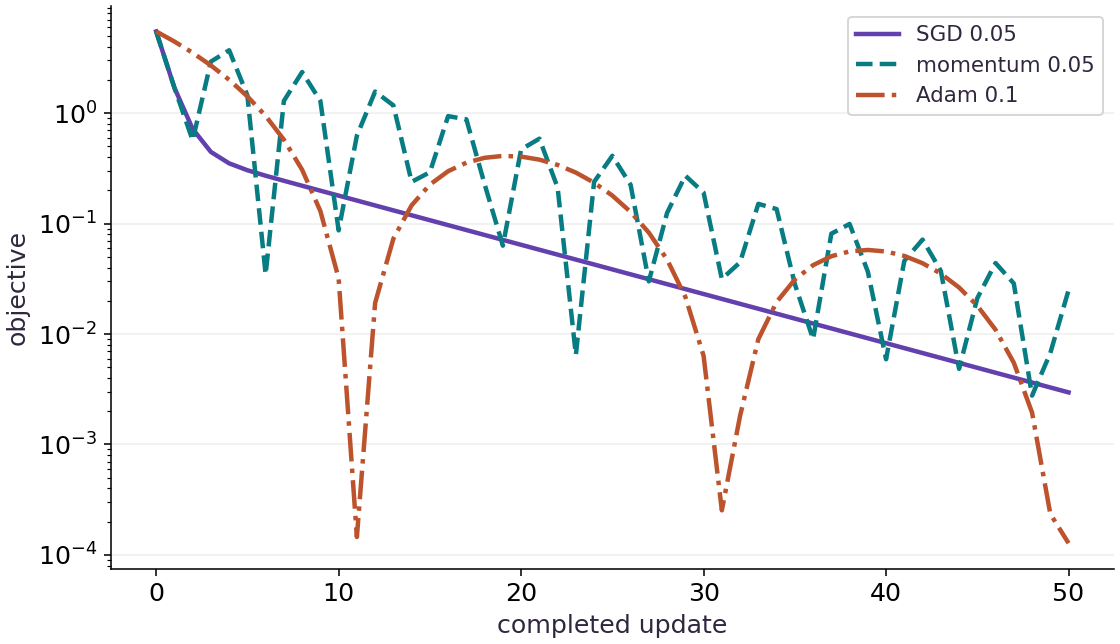

In [6]:
# Render the figure from the data computed above. Change the data experiment and rerun.
import matplotlib.pyplot as plt
plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 13, 'axes.labelcolor': '#30273e', 'text.color': '#30273e'})
def draw_panel(ax, data):
    import numpy as np
    palette = ['#6240ad', '#087c83', '#bc532c', '#405d9d']
    kind = data['kind']
    if kind in ('heatmap', 'field'):
        a = np.asarray(data['values'], dtype=float)
        assert a.ndim == 2 and np.isfinite(a).all()
        kw = {'cmap': 'PuOr' if data.get('diverging') else 'Purples', 'aspect': 'auto'}
        if kind == 'field':
            kw.update(extent=data['extent'], origin='lower', vmin=0, vmax=1)
        elif data.get('diverging'):
            limit = max(float(np.abs(a).max()), 1e-10)
            kw.update(vmin=-limit, vmax=limit)
        if data.get('scale') == 'probability' or data['unit'] in ('attention weight', 'next-token probability', 'masked-token probability'):
            kw.update(vmin=0, vmax=1)
        categorical = data.get('scale') == 'categorical' or any(name in data['unit'] for name in ('device ID','program ID'))
        if categorical:
            from matplotlib.colors import ListedColormap, BoundaryNorm
            from matplotlib import colormaps
            ids=np.unique(a).astype(int)
            boundaries=np.r_[ids[0]-.5,(ids[:-1]+ids[1:])/2,ids[-1]+.5]
            kw.update(cmap=ListedColormap([colormaps['tab20'](i) for i in range(len(ids))]), norm=BoundaryNorm(boundaries,len(ids)))
        im = ax.imshow(a, **kw)
        ax.figure.colorbar(im, ax=ax, shrink=0.8, label=data['unit'], **({'ticks':ids} if categorical else {}))
        if kind == 'heatmap':
            if a.size <= 32:
                mid = (float(a.min()) + float(a.max())) / 2
                for (i, j), value in np.ndenumerate(a):
                    rgb=im.cmap(im.norm(value))[:3]
                    luminance=sum(c*w for c,w in zip(rgb,[0.2126,0.7152,0.0722]))
                    ax.text(j, i, f'{value:.3g}', ha='center', va='center', fontsize=11,
                            color='white' if luminance < 0.5 else '#20202c')
            ax.set_xticks(range(a.shape[1]), data.get('columns', [str(i) for i in range(a.shape[1])]))
            ax.set_yticks(range(a.shape[0]), data.get('rows', [str(i) for i in range(a.shape[0])]))
            if a.shape[1] > 5: ax.tick_params(axis='x', labelsize=11)
        else:
            pts = np.asarray(data['points']); labels = np.asarray(data['labels'])
            for label, marker in [(0, 'o'), (1, '^')]:
                selected = pts[labels == label]
                ax.scatter(selected[:, 0], selected[:, 1], label=f'observed label {label}', marker=marker,
                           s=38, facecolors='white' if label == 0 else '#f4b547', edgecolors='#272238', linewidths=1)
            ax.legend(loc='upper left', fontsize=10)
    elif kind in ('line', 'bar'):
        series = data['series']
        x = np.asarray(data.get('x', list(range(len(data.get('labels', []))))))
        assert len(x) and np.isfinite(x).all()
        for i, s in enumerate(series):
            y = np.asarray(s['y'], dtype=float)
            assert y.shape == x.shape and np.isfinite(y).all(), s['label']
            if data.get('yscale') == 'log': assert (y > 0).all()
            if kind == 'line':
                ax.plot(x, y, color=palette[i % len(palette)], label=s['label'], linewidth=2.3,
                        linestyle=['-', '--', '-.', ':'][i % 4], marker='o' if len(x) <= 25 else None, markersize=3)
            else:
                width = 0.78 / len(series)
                bars = ax.bar(x + (i - (len(series)-1)/2)*width, y, width, label=s['label'], color=palette[i % len(palette)])
                if len(x)*len(series) <= 12: ax.bar_label(bars, fmt='%.3g', fontsize=10, padding=3)
        if kind == 'bar':
            ax.set_xticks(x, data['labels'])
            ax.margins(y=0.17)
            if any(len(t) > 13 for t in data['labels']): ax.tick_params(axis='x', labelrotation=15, labelsize=11)
        if data.get('xscale'): ax.set_xscale(data['xscale'])
        if data.get('yscale'): ax.set_yscale(data['yscale'], **({'linthresh':data.get('linthresh',2)} if data['yscale']=='symlog' else {}))
        for marker in data.get('markers',[]):
            ax.scatter([marker['x']],[marker['y']],color='#bc532c',s=45,zorder=5)
            ax.annotate(marker['label'],(marker['x'],marker['y']),xytext=(-85,12),textcoords='offset points',fontsize=10)
        for boundary in data.get('boundaries', []): ax.axvline(boundary, color='#716e7b', linestyle=':', linewidth=1)
        ax.grid(axis='y', alpha=0.2)
        ax.legend(fontsize=11, loc='best')
    elif kind == 'vectors':
        for i, arrow in enumerate(data['arrows']):
            start = np.asarray(arrow['start']); end = np.asarray(arrow['end'])
            ax.annotate('', xy=end, xytext=start, arrowprops={'arrowstyle':'->','color':palette[i], 'lw':2.8})
            mid=(start+end)/2
            ax.annotate(arrow['label'], mid, xytext=(7,7), textcoords='offset points', color=palette[i])
        ax.set(xlim=(-0.7,4.5),ylim=(-0.7,5),xlabel='first coordinate',ylabel='second coordinate')
        ax.set_aspect('equal'); ax.grid(alpha=0.2)
    elif kind == 'flow':
        from matplotlib.patches import FancyBboxPatch
        nodes=data['nodes']; ax.set(xlim=(0,1),ylim=(0,len(nodes))); ax.axis('off')
        if data.get('layout') == 'merge':
            import textwrap
            for i,label in enumerate(nodes[:3]):
                x=0.02+i*0.33
                ax.add_patch(FancyBboxPatch((x,3.7),0.29,1.0,boxstyle='round,pad=0.015',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(x+0.145,4.2,textwrap.fill(label,20),ha='center',va='center',fontsize=11)
                ax.annotate('',(0.5,2.8),(x+0.145,3.67),arrowprops={'arrowstyle':'->','color':'#6240ad'})
            for y,label in [(2.4,nodes[3]),(0.9,nodes[4])]:
                ax.add_patch(FancyBboxPatch((0.08,y-0.35),0.84,0.7,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
            ax.annotate('',(0.5,1.3),(0.5,2.0),arrowprops={'arrowstyle':'->','color':'#6240ad'})
        else:
            for i, label in enumerate(nodes):
                y=len(nodes)-i-0.5
                ax.add_patch(FancyBboxPatch((0.08,y-0.3),0.84,0.6,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
                if i<len(nodes)-1: ax.annotate('',(0.5,y-0.67),(0.5,y-0.32),arrowprops={'arrowstyle':'->','color':'#6240ad'})
    else: raise ValueError(f'Unknown figure kind: {kind}')
    if data.get('xlabel'): ax.set_xlabel(data['xlabel'])
    if data.get('ylabel'): ax.set_ylabel(data['ylabel'])
    if data.get('title'): ax.set_title(data['title'], loc='left', fontsize=12, pad=12)
    for spine in ('top','right'): ax.spines[spine].set_visible(False)


def draw_mechanism(ax, diagram):
    """Draw a source-authored conceptual/analytic mechanism, never measured data."""
    import numpy as np
    from matplotlib.patches import FancyBboxPatch, Rectangle, Circle, Ellipse
    panel = diagram['panel']
    kind = panel['kind']
    colors = {'data':('#eef3ff','#3559a8'), 'state':('#f0eafa','#6240ad'),
              'fixed':('#f1f3f5','#536273'), 'result':('#e5f4ee','#17735c'),
              'warning':('#fff0e6','#a64d20')}
    if kind == 'graph':
        ax.set(xlim=(0,panel.get('width',10)),ylim=(panel.get('height',8),0))
        ax.axis('off')
        nodes={node['id']:node for node in panel['nodes']}
        for edge in panel['edges']:
            a,b=nodes[edge['from']],nodes[edge['to']]
            side_a=edge.get('exit','bottom'); side_b=edge.get('enter','top')
            def port(node,side):
                x,y=node['x'],node['y']; w,h=node.get('w',3),node.get('h',.8)
                return {'top':(x,y-h/2),'bottom':(x,y+h/2),'left':(x-w/2,y),'right':(x+w/2,y)}[side]
            start,end=port(a,side_a),port(b,side_b)
            ax.annotate('',xy=end,xytext=start,arrowprops={'arrowstyle':'-|>','color':'#536273','lw':1.7,'connectionstyle':edge.get('curve','arc3,rad=0')},zorder=1)
            if edge.get('label'):
                tx,ty=edge.get('labelAt',((start[0]+end[0])/2,(start[1]+end[1])/2))
                ax.text(tx,ty,edge['label'],ha='center',va='center',fontsize=10,color='#394658',bbox={'facecolor':'white','edgecolor':'none','pad':2},zorder=4)
        for node in panel['nodes']:
            fill,stroke=colors[node.get('tone','data')]
            x,y=node['x'],node['y'];w,h=node.get('w',3),node.get('h',.8)
            ax.add_patch(FancyBboxPatch((x-w/2,y-h/2),w,h,boxstyle='round,pad=0.02,rounding_size=0.07',facecolor=fill,edgecolor=stroke,lw=1.5,zorder=2))
            ax.text(x,y,node['label'],ha='center',va='center',fontsize=node.get('fontSize',12),color='#172334',zorder=3)
    elif kind == 'table':
        ax.axis('off')
        table=ax.table(cellText=panel['rows'],colLabels=panel['headers'],cellLoc='center',loc='center',colWidths=panel.get('widths'))
        table.auto_set_font_size(False);table.set_fontsize(12);table.scale(1,2.7)
        for (row,col),cell in table.get_celld().items():
            cell.set_edgecolor('#ccd3df')
            cell.set_facecolor('#e9e4f5' if row==0 else ('#f4f7fb' if row%2 else '#ffffff'))
            cell.set_text_props(color='#172334',weight='bold' if row==0 else 'normal')
    elif kind == 'clipping':
        ax.add_patch(Circle((0,0),2.5,fill=False,edgecolor='#17735c',linestyle='--',lw=1.8))
        ax.add_patch(Rectangle((-2.5,-2.5),5,5,fill=False,edgecolor='#a64d20',linestyle=':',lw=1.8))
        for end,color,label,offset in [((3,4),'#3559a8','Original (3, 4)',(8,5)),((1.5,2),'#17735c','Norm clip (1.5, 2)',(-126,-16)),((2.5,2.5),'#a64d20','Coordinate clip (2.5, 2.5)',(8,-2))]:
            ax.annotate('',xy=end,xytext=(0,0),arrowprops={'arrowstyle':'-|>','color':color,'lw':2.6})
            ax.annotate(label,end,xytext=offset,textcoords='offset points',color=color,fontsize=11)
        ax.set(xlim=(-3,5.8),ylim=(-3,4.8),xlabel='gradient coordinate 1',ylabel='gradient coordinate 2')
        ax.set_aspect('equal');ax.grid(alpha=.15)
    elif kind == 'patches':
        ax.set(xlim=(-.1,4.1),ylim=(4.1,-.1));ax.set_aspect('equal');ax.axis('off')
        for i in range(4):
            x,y=(i%2)*2,(i//2)*2
            visible=i in [0,3]
            ax.add_patch(Rectangle((x,y),2,2,facecolor='#e5f4ee' if visible else '#fff0e6',edgecolor='#17735c' if visible else '#a64d20',hatch=None if visible else '///',lw=2))
            ax.text(x+1,y+1,f'Patch {i}\n'+('visible input' if visible else 'hidden target'),ha='center',va='center',fontsize=14,bbox={'facecolor':'white','edgecolor':'none','alpha':.94,'pad':5})
        for a in [1,3]:
            ax.axhline(a,color='#172334',alpha=.25,lw=.7);ax.axvline(a,color='#172334',alpha=.25,lw=.7)
    elif kind == 'receptive-field':
        ax.set(xlim=(-.15,5.15),ylim=(5.15,-.15));ax.set_aspect('equal');ax.axis('off')
        for row in range(5):
            for col in range(5):
                selected=1<=row<=3 and 1<=col<=3
                ax.add_patch(Rectangle((col,row),1,1,facecolor='#e9e4f5' if selected else '#f4f7fb',edgecolor='#a6afc1',lw=1))
                ax.text(col+.5,row+.5,f'{row},{col}',ha='center',va='center',fontsize=12)
        ax.add_patch(Rectangle((1,1),3,3,fill=False,edgecolor='#6240ad',lw=3))
        ax.set_title('One 3 × 3 receptive field inside a 5 × 5 input',fontsize=13,pad=12)
    elif kind == 'covariance':
        for covariance,color,label in [(np.array([[1,.8],[.8,1]]),'#6240ad','Correlated covariance'),(np.eye(2),'#17735c','Same marginals, zero covariance')]:
            eig,vec=np.linalg.eigh(covariance);order=np.argsort(eig)[::-1];eig=eig[order];vec=vec[:,order]
            angle=np.degrees(np.arctan2(vec[1,0],vec[0,0]))
            ax.add_patch(Ellipse((0,0),2*np.sqrt(eig[0]),2*np.sqrt(eig[1]),angle=angle,fill=False,lw=2.5,edgecolor=color,label=label))
        ax.set(xlim=(-1.8,1.8),ylim=(-1.8,1.8),xlabel='first variable',ylabel='second variable')
        ax.set_aspect('equal');ax.grid(alpha=.2);ax.legend(loc='upper center',bbox_to_anchor=(.5,-.14),fontsize=10)
    elif kind == 'timeline':
        ax.set(xlim=(0,10),ylim=(-.7,2.7),yticks=[0,1,2],yticklabels=['Host','Device','Measurement'])
        for start,length,y,label,color in [(0,1,0,'dispatch','#3559a8'),(1,6,1,'device work','#6240ad'),(1,6,0,'wait for result','#a64d20'),(0,7,2,'completed-result interval','#17735c')]:
            ax.barh(y,length,left=start,height=.45,color=color,alpha=.18)
            ax.text(start+length/2,y,label,ha='center',va='center',fontsize=11)
        ax.axvline(7,color='#536273',linestyle='--');ax.text(7.1,.5,'result ready',fontsize=11)
        ax.set_xlabel('conceptual order; lengths are not measured durations')
        ax.invert_yaxis()
    else:
        raise ValueError(f'Unknown mechanism kind: {kind}')

panels = visual_data.get('panels', [visual_data])
fig, axes = plt.subplots(len(panels), 1, figsize=(8, 4.6 * len(panels)), squeeze=False, layout='constrained')
for ax, panel in zip(axes[:, 0], panels):
    draw_panel(ax, panel)
plt.show()

### Read the figure

Start with the axes. The horizontal axis counts completed parameter updates; $0$ is the shared starting point. The vertical axis is the objective $L(w)=\tfrac12(w_0^2+10w_1^2)$, so lower is better. It is logarithmic: falling from $10^{-2}$ to $10^{-3}$ means a tenfold reduction, not a decrease of one unit. Zero cannot appear on this scale.

All three methods begin at $w=(1,1)$, with loss $5.5$. The solid SGD curve drops smoothly and then develops a slower tail. With learning rate $0.05$, each update multiplies the two coordinates by $0.95$ and $0.5$. The steep direction shrinks quickly; the flatter direction accounts for the slow remaining progress.

### Connect it to the computation

Now follow the dashed momentum curve. Its loss falls to about $0.568$ at update $2$, then rises to about $3.714$ at update $4$. Momentum retains past gradients, so a favorable current position does not guarantee a favorable next step: the accumulated update can carry the parameters past the minimum. The repeated dips and rebounds occur under a generally declining envelope. They are deterministic optimizer behavior in this example, not noise from shuffled minibatches.

The dash-dot Adam curve makes the same caution especially clear. It reaches about $1.45\times10^{-4}$ at update $11$, then rises to about $0.410$ by update $19$. Adam adapts coordinate-wise update sizes using gradient history, but that history can still move parameters away after a close approach. A deep dip means the current parameters are near the minimum; it does not mean subsequent updates will stay there. The scalar loss alone does not tell us which side of the minimum each coordinate occupies.

At update $50$, the losses are approximately $1.28\times10^{-4}$ for Adam, $2.96\times10^{-3}$ for SGD, and $2.49\times10^{-2}$ for momentum. Adam finishes lowest under these settings, although it was not lowest at every earlier update. Compare the same update budget, read the endpoint as well as the dips, and remember that equal update counts do not imply equal runtime. This figure uses fixed rates without clipping or a schedule; the later experiments examine those separate choices.

## Inspect the schedule boundary

Predict: List the rates used by the first five updates. Is the fifth rate already the final value?

In [7]:
# Experiment — Inspect the schedule boundary: A schedule is indexed by optimizer updates.
# Configure or step the Optax optimizer state (`schedule`).
schedule = optax.linear_schedule(init_value=0.1, end_value=0.01, transition_steps=4)
# Initialize array `rates` with explicit values and shape.
rates = jnp.array([schedule(i) for i in range(6)])
# Verify that the numerical values match the expected reference within tolerance.
assert jnp.allclose(rates, jnp.array([0.1, 0.0775, 0.055, 0.0325, 0.01, 0.01]), atol=1e-06)
# Configure or step the Optax optimizer state (`tx`).
tx = optax.sgd(schedule)
# Initialize array `p` with explicit values and shape.
p = jnp.array(0.0)
# Run `tx.init` to compute `s`.
s = tx.init(p)
# Repeat the update loop over `range(5)` steps:
for _ in range(5):
    # Initialize array `(delta, s)` with explicit values and shape.
    delta, s = tx.update(jnp.array(1.0), s, p)
    # Configure or step the Optax optimizer state (`p`).
    p = optax.apply_updates(p, delta)
# Verify that the numerical values match the expected reference within tolerance.
assert jnp.allclose(p, -0.275, atol=1e-06)
# Print the observed values to compare against the expected result.
print('schedule rates:', rates)

schedule rates: [0.1    0.0775 0.055  0.0325 0.01   0.01  ]


Expected: The fifth update uses count $4$ and rate $0.01$.

A schedule is indexed by optimizer updates. Recording only the number of epochs leaves its behavior ambiguous.

## Compare a fixed update budget

Predict: Will every optimizer produce the same path on a bowl with unequal curvature?

In [8]:
# Experiment — Compare a fixed update budget: This is a controlled demonstration at stated rates and update...
def bowl(w):
    # Return `0.5 * (w[0] ** 2 + 10 * w[1] ** 2)` to the caller.
    return 0.5 * (w[0] ** 2 + 10 * w[1] ** 2)
# Initialize array `start` with explicit values and shape.
start = jnp.array([1.0, 1.0])
# Configure or step the Optax optimizer state (`optimizers`).
optimizers = {'sgd': optax.sgd(0.05), 'momentum': optax.sgd(0.05, momentum=0.9), 'adam': optax.adam(0.1)}
# Evaluate `traces` from the current inputs and state.
traces = {}
# Iterate over `(name, tx)` to step through the computation:
for name, tx in optimizers.items():

    # Define `step(carry, _)` to evaluate the objective and its automatic derivatives:
    def step(carry, _):
        # Evaluate `(p, s)` from the current inputs and state.
        p, s = carry
        # Differentiate the objective to obtain `(delta, s)` via automatic differentiation.
        delta, s = tx.update(jax.grad(bowl)(p), s, p)
        # Configure or step the Optax optimizer state (`p`).
        p = optax.apply_updates(p, delta)
        # Return `((p, s), bowl(p))` to the caller.
        return ((p, s), bowl(p))
    # Run compiled structured control flow via `jax.lax` (`((_, _), history)`).
    (_, _), history = jax.lax.scan(step, (start, tx.init(start)), None, length=50)
    # Confirm that all computed values remain finite (no NaN or Inf).
    assert jnp.all(jnp.isfinite(history))
    # Verify that the output satisfies the expected shape, finite-value, or numerical contract.
    assert history[-1] < bowl(start)
    # Evaluate `traces[name]` from the current inputs and state.
    traces[name] = history
    # Print diagnostic summary of the computed outputs.
    print(name, 'initial / final loss:', bowl(start), history[-1])
# Verify that the numerical values match the expected reference within tolerance.
assert not jnp.allclose(traces['sgd'], traces['adam'])

sgd initial / final loss: 5.5 0.0029602647
momentum initial / final loss: 5.5 0.024945451
adam initial / final loss: 5.5 0.00012754407


Expected: All three reduce the loss for these specified settings; the trajectories differ.

This is a controlled demonstration at stated rates and update counts, not evidence that one optimizer universally wins.

## Your exercise

Compare global norm clipping with coordinate-wise clipping on $(3,4)$. Check which preserves the ratio of the coordinates.

### How to write this exercise — Step-by-step recipe & starter scaffold

**Key functions & syntax to use:**
- `jnp.array(values, dtype=...)` — Constructs an immutable device-backed JAX array from Python/NumPy values.
- `jnp.allclose(actual, expected, rtol=..., atol=...)` — Checks that two arrays match elementwise within floating-point tolerance.

**Step-by-step implementation plan:**
1. Verify that the numerical values match the expected reference within tolerance.
2. Verify that the output satisfies the expected shape, finite-value, or numerical contract.
3. Verify that the output satisfies the expected shape, finite-value, or numerical contract.

**Starter code scaffold (fill in the TODOs):**

```python
# Exercise solution: Compare global norm clipping with coordinate-wise clipping on (3,4).
coordinate = jnp.clip(...)  # TODO: compute coordinate
# Verify that the numerical values match the expected reference within tolerance.
assert jnp.allclose(coordinate, jnp.array([1.0, 1.0]))  # TODO: complete assertion check
# Verify that the output satisfies the expected shape, finite-value, or numerical contract.
assert jnp.allclose(clipped[0] / clipped[1], g[0] / g[1])  # TODO: complete assertion check
# Verify that the output satisfies the expected shape, finite-value, or numerical contract.
assert not jnp.allclose(coordinate[0] / coordinate[1], g[0] / g[1])  # TODO: complete assertion check
```

In [9]:
# Write your attempt here (uncomment and fill in the TODOs below):
# Exercise solution: Compare global norm clipping with coordinate-wise clipping on (3,4).
# coordinate = jnp.clip(...)  # TODO: compute coordinate
# Verify that the numerical values match the expected reference within tolerance.
# assert jnp.allclose(coordinate, jnp.array([1.0, 1.0]))  # TODO: complete assertion check
# Verify that the output satisfies the expected shape, finite-value, or numerical contract.
# assert jnp.allclose(clipped[0] / clipped[1], g[0] / g[1])  # TODO: complete assertion check
# Verify that the output satisfies the expected shape, finite-value, or numerical contract.
# assert not jnp.allclose(coordinate[0] / coordinate[1], g[0] / g[1])  # TODO: complete assertion check

## Reference solution

Try your own implementation first.

In [10]:
# Exercise solution: Compare global norm clipping with coordinate-wise clipping on (3,4).
coordinate = jnp.clip(g, -1.0, 1.0)
# Verify that the numerical values match the expected reference within tolerance.
assert jnp.allclose(coordinate, jnp.array([1.0, 1.0]))
# Verify that the output satisfies the expected shape, finite-value, or numerical contract.
assert jnp.allclose(clipped[0] / clipped[1], g[0] / g[1])
# Verify that the output satisfies the expected shape, finite-value, or numerical contract.
assert not jnp.allclose(coordinate[0] / coordinate[1], g[0] / g[1])

## Catch schedule restart · Transfer / diagnosis

After five scheduled SGD steps with constant gradient $1$, compare a retained optimizer state with a freshly initialized state for the next update.

Hint: The retained count has reached the final rate; a reset count starts at $0$.

### How to write: Catch schedule restart — Step-by-step recipe & starter scaffold

**Key functions & syntax to use:**
- `jnp.array(values, dtype=...)` — Constructs an immutable device-backed JAX array from Python/NumPy values.
- `jnp.allclose(actual, expected, rtol=..., atol=...)` — Checks that two arrays match elementwise within floating-point tolerance.
- `optax.adam(lr) / optax.apply_updates(params, updates)` — Optax gradient transformations and numerically stable loss functions over parameter PyTrees.

**Step-by-step implementation plan:**
1. Configure or step the Optax optimizer state (`tx`).
2. Initialize array `p` with explicit values and shape.
3. Run `tx.init` to compute `s`.
4. Repeat the update loop over `range(5)` steps:
5. Initialize array `(delta, s)` with explicit values and shape.

**Starter code scaffold (fill in the TODOs):**

```python
# Catch schedule restart (Transfer / diagnosis): Restoring weights without optimizer state can silently...
# Configure or step the Optax optimizer state (`tx`).
tx = optax.sgd(...)  # TODO: compute tx
# Initialize array `p` with explicit values and shape.
p = jnp.array(...)  # TODO: compute p
# Run `tx.init` to compute `s`.
s = tx.init(...)  # TODO: compute s
# Repeat the update loop over `range(5)` steps:
for _ in range(5):
    # Initialize array `(delta, s)` with explicit values and shape.
    delta, s = tx.update(...)  # TODO: compute delta, s
    # Configure or step the Optax optimizer state (`p`).
    p = optax.apply_updates(...)  # TODO: compute p
# Initialize array `(continued, _)` with explicit values and shape.
continued, _ = tx.update(...)  # TODO: compute continued, _
# Initialize array `(restarted, _)` with explicit values and shape.
restarted, _ = tx.update(...)  # TODO: compute restarted, _
# Verify that the numerical values match the expected reference within tolerance.
assert jnp.allclose(continued, -0.01, atol=1e-06)  # TODO: complete assertion check
# Verify that the output satisfies the expected shape, finite-value, or numerical contract.
assert jnp.allclose(restarted, -0.1, atol=1e-06)  # TODO: complete assertion check
```

In [11]:
# Write your attempt here (uncomment and fill in the TODOs below):
# Catch schedule restart (Transfer / diagnosis): Restoring weights without optimizer state can silently...
# Configure or step the Optax optimizer state (`tx`).
# tx = optax.sgd(...)  # TODO: compute tx
# Initialize array `p` with explicit values and shape.
# p = jnp.array(...)  # TODO: compute p
# Run `tx.init` to compute `s`.
# s = tx.init(...)  # TODO: compute s
# Repeat the update loop over `range(5)` steps:
# for _ in range(5):
    # Initialize array `(delta, s)` with explicit values and shape.
#     delta, s = tx.update(...)  # TODO: compute delta, s
    # Configure or step the Optax optimizer state (`p`).
#     p = optax.apply_updates(...)  # TODO: compute p
# Initialize array `(continued, _)` with explicit values and shape.
# continued, _ = tx.update(...)  # TODO: compute continued, _
# Initialize array `(restarted, _)` with explicit values and shape.
# restarted, _ = tx.update(...)  # TODO: compute restarted, _
# Verify that the numerical values match the expected reference within tolerance.
# assert jnp.allclose(continued, -0.01, atol=1e-06)  # TODO: complete assertion check
# Verify that the output satisfies the expected shape, finite-value, or numerical contract.
# assert jnp.allclose(restarted, -0.1, atol=1e-06)  # TODO: complete assertion check

## Reference reasoning

Restoring weights without optimizer state can silently restart the learning-rate schedule.

In [12]:
# Catch schedule restart (Transfer / diagnosis): Restoring weights without optimizer state can silently...
# Configure or step the Optax optimizer state (`tx`).
tx = optax.sgd(schedule)
# Initialize array `p` with explicit values and shape.
p = jnp.array(0.0)
# Run `tx.init` to compute `s`.
s = tx.init(p)
# Repeat the update loop over `range(5)` steps:
for _ in range(5):
    # Initialize array `(delta, s)` with explicit values and shape.
    delta, s = tx.update(jnp.array(1.0), s, p)
    # Configure or step the Optax optimizer state (`p`).
    p = optax.apply_updates(p, delta)
# Initialize array `(continued, _)` with explicit values and shape.
continued, _ = tx.update(jnp.array(1.0), s, p)
# Initialize array `(restarted, _)` with explicit values and shape.
restarted, _ = tx.update(jnp.array(1.0), tx.init(p), p)
# Verify that the numerical values match the expected reference within tolerance.
assert jnp.allclose(continued, -0.01, atol=1e-06)
# Verify that the output satisfies the expected shape, finite-value, or numerical contract.
assert jnp.allclose(restarted, -0.1, atol=1e-06)

## Check transformation order · Transfer / diagnosis

For gradient $(3,4)$, compare clipping before SGD at rate $0.1$ with clipping after it. Write a decision memo explaining which quantity you intended to bound.

Hint: The un-clipped SGD update already has norm $0.5$, below the threshold $1$.

### How to write: Check transformation order — Step-by-step recipe & starter scaffold

**Key functions & syntax to use:**
- `jnp.zeros / jnp.ones(shape, dtype=...)` — Allocates a tensor of the given `shape` initialized with constants.
- `jnp.allclose(actual, expected, rtol=..., atol=...)` — Checks that two arrays match elementwise within floating-point tolerance.
- `optax.adam(lr) / optax.apply_updates(params, updates)` — Optax gradient transformations and numerically stable loss functions over parameter PyTrees.

**Step-by-step implementation plan:**
1. Configure or step the Optax optimizer state (`before`).
2. Configure or step the Optax optimizer state (`after`).
3. Initialize array `(u_before, _)` with explicit values and shape.
4. Initialize array `(u_after, _)` with explicit values and shape.
5. Verify that the numerical values match the expected reference within tolerance.

**Starter code scaffold (fill in the TODOs):**

```python
# Check transformation order (Transfer / diagnosis): Transformation order changes the algorithm.
# Configure or step the Optax optimizer state (`before`).
before = optax.chain(...)  # TODO: compute before
# Configure or step the Optax optimizer state (`after`).
after = optax.chain(...)  # TODO: compute after
# Initialize array `(u_before, _)` with explicit values and shape.
u_before, _ = before.update(...)  # TODO: compute u_before, _
# Initialize array `(u_after, _)` with explicit values and shape.
u_after, _ = after.update(...)  # TODO: compute u_after, _
# Verify that the numerical values match the expected reference within tolerance.
assert jnp.allclose(jnp.linalg.norm(u_before), 0.1, atol=1e-06)  # TODO: complete assertion check
# Verify that the output satisfies the expected shape, finite-value, or numerical contract.
assert jnp.allclose(jnp.linalg.norm(u_after), 0.5, atol=1e-06)  # TODO: complete assertion check
```

In [13]:
# Write your attempt here (uncomment and fill in the TODOs below):
# Check transformation order (Transfer / diagnosis): Transformation order changes the algorithm.
# Configure or step the Optax optimizer state (`before`).
# before = optax.chain(...)  # TODO: compute before
# Configure or step the Optax optimizer state (`after`).
# after = optax.chain(...)  # TODO: compute after
# Initialize array `(u_before, _)` with explicit values and shape.
# u_before, _ = before.update(...)  # TODO: compute u_before, _
# Initialize array `(u_after, _)` with explicit values and shape.
# u_after, _ = after.update(...)  # TODO: compute u_after, _
# Verify that the numerical values match the expected reference within tolerance.
# assert jnp.allclose(jnp.linalg.norm(u_before), 0.1, atol=1e-06)  # TODO: complete assertion check
# Verify that the output satisfies the expected shape, finite-value, or numerical contract.
# assert jnp.allclose(jnp.linalg.norm(u_after), 0.5, atol=1e-06)  # TODO: complete assertion check

## Reference reasoning

Transformation order changes the algorithm. State whether the bound applies to the raw gradient or the parameter update, and retain the observed evidence.

In [14]:
# Check transformation order (Transfer / diagnosis): Transformation order changes the algorithm.
# Configure or step the Optax optimizer state (`before`).
before = optax.chain(optax.clip_by_global_norm(1.0), optax.sgd(0.1))
# Configure or step the Optax optimizer state (`after`).
after = optax.chain(optax.sgd(0.1), optax.clip_by_global_norm(1.0))
# Initialize array `(u_before, _)` with explicit values and shape.
u_before, _ = before.update(g, before.init(jnp.zeros(2)))
# Initialize array `(u_after, _)` with explicit values and shape.
u_after, _ = after.update(g, after.init(jnp.zeros(2)))
# Verify that the numerical values match the expected reference within tolerance.
assert jnp.allclose(jnp.linalg.norm(u_before), 0.1, atol=1e-06)
# Verify that the output satisfies the expected shape, finite-value, or numerical contract.
assert jnp.allclose(jnp.linalg.norm(u_after), 0.5, atol=1e-06)

## Checkpoint

Does clipping gradients before Adam guarantee that final updates obey the same norm threshold?

1. Yes, every later transformation preserves that bound
2. No; Adam subsequently rescales coordinates
3. Only if the loss is a scalar

## Diagnose

If a restart changes the trajectory, compare optimizer moments and schedule count. If a clipped run still jumps, measure both gradient and update norms and inspect transformation order. Record rates, reductions, dtype and validation behavior before recommending a method.

## Evidence

Keep two hand-checked Adam steps, clipping-direction checks, schedule values and boundary, equal-budget loss traces, and the optimization decision memo.

## Carry forward

- A schedule is indexed by optimizer updates. Recording only the number of epochs leaves its behavior ambiguous.
- This is a controlled demonstration at stated rates and update counts, not evidence that one optimizer universally wins.

## Primary references

- [Optax Adam](https://optax.readthedocs.io/en/latest/api/optimizers.html#optax.adam)
- [Optax transformations](https://optax.readthedocs.io/en/latest/api/transformations.html)
- [Optax schedules](https://optax.readthedocs.io/en/latest/api/optimizer_schedules.html)